# Torch-Rechub 新手教程：使用DeepFM进行CTR(点击率)预测

本教程使用 `torch-rechub` 库，以经典的 ML-1M数据集为例，演示从数据读取到模型训练的完整 CTR 预测流程。  
**什么是CTR预测？ (Click-Through Rate Prediction)**  
```text
通俗来说，就是“猜你点不点”，并且给出一个精确的概率。  
字面意思：CTR 的全称是 Click-Through Rate（点击率）。在历史数据中，点击率 = 点击次数 / 展示次数。  
模型层面的意思：这是一个典型的二分类问题（点=1，不点=0）。当你把一个“用户”和一个“商品（或广告）”的信息喂给机器学习模型时，模型会输出一个 0 到 1 之间的小数。   
比如输出 0.85，意思是：模型预测这个用户有 85% 的概率会点击这个广告。  
比如输出 0.01，意思是：模型预测这个用户根本不感兴趣，只有 1% 的可能会点。  
公式化理解： CTR = 预估概率(User, Item, Context)  
（给定这个用户、这个商品、以及当前的上下文环境如时间和地点，求点击的概率）。  
```
**为什么要做CTR预测？**  
```text
在互联网大厂（如字节跳动、阿里、腾讯、Criteo），CTR 预估模型被称为“印钞机”。这主要有以下三个核心原因：  
```
1. 核心商业模式：为了最大化赚钱 (流量变现)  
```text
互联网广告最常见的收费模式是 CPC (Cost Per Click，按点击计费)。也就是说，广告展示出来不收钱，用户点进去了才收钱。  
假设你是一个平台老板，你有两个广告主来竞价：  
广告 A（卖别墅）：点一次老板愿意出价 100元。但因为买得起的人少，模型预测它的 CTR 只有 0.1%。  
广告 B（卖纸巾）：点一次老板只愿意出价 1元。但因为是刚需，模型预测它的 CTR 高达 20%。  
平台该展示哪个才能赚最多？  
展示 A 的期望收益：100元 × 0.1% = 0.1元  
展示 B 的期望收益：1元 × 20% = 0.2元  
结论：展示卖纸巾的广告 B 赚得更多！  
总结：如果没有精准的 CTR 预测，平台就不知道每次展示能赚多少钱。CTR 预测越准，平台赚的钱就越多。  
```
2. 推荐系统的灵魂：为了给内容排序 (Ranking)  
```text
当你打开淘宝、抖音或小红书时，后台的数据库里有千万级别的商品或视频。  
手机屏幕那么小，谁排在第一屏，谁排在后面？  
这时候，系统就会调用 CTR 模型，给候选的几千个商品全部打上“点击概率”的分数，然后按照分数从高到低排序。排在最前面的，就是你一打开手机看到的内容。CTR 模型直接决定了整个推荐系统的展示顺序。  
```
3. 保护用户体验：为了不招人烦  
```text
如果我们只为了赚钱，给用户满屏推劣质的诱导点击广告，用户明天就卸载 App 了。  
精准的 CTR 预测，本质上也是在精准猜测用户的心智和喜好。只给用户推他们真正感兴趣（预测 CTR 高）的内容，既能让商家把东西卖出去，又能让用户刷得开心，实现平台、商家、用户的三赢。  
```
**CTR预测与召回的联系？**
```text
在推荐系统中，CTR 预测经常被用于排序。排序与召回（Recall）是“上下游”的互补关系：
召回（Recall）负责“广度”：
正如我们在 DSSM 模型中看到的，召回的任务是从 1 亿个物品中快速捞出 500 个候选者。它像是一个初审面试官，任务是“别漏掉好苗子”，但它没法对这 500 个人进行非常精细的打分。
排序负责“深度”：
它像是一个主考官，专门负责精挑细选。它只针对召回送来的这 500 个物品，利用更复杂的特征（比如用户历史行为序列的 Attention 机制）进行“毫厘之间”的打分。
```


## 0. 流程总览
我们将遵循以下步骤：
1. **环境设置**：导入所需库并定义全局参数。
2. **数据加载与预处理**：加载 ML-1M 数据集，并将其从评分预测任务转换为二元分类（CTR 预估）任务。
3. **特征工程**：对类别特征进行标签编码（Label Encoding）。
4. **特征封装**：使用 `torch-rechub` 的 `SparseFeature` 和 `DenseFeature` 类来定义模型输入。
5. **数据生成器**：创建用于训练、验证和测试的 DataLoader。
6. **模型构建**：初始化 DeepFM 模型。
7. **模型训练与评估**：使用 `CTRTrainer` 来训练模型，并在测试集上评估其性能（AUC）。

## 1. 环境设置与参数定义

首先，我们导入所有必要的库。这包括数据处理的 `pandas` 和 `numpy`，模型训练的 `torch`，以及 `torch-rechub` 提供的各种工具和模型。我们还定义了一些超参数，如数据集路径、批量大小（Batch Size）、学习率（Learning Rate）、训练轮数（Epoch）和设备（CPU/GPU）。

In [10]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import torch
from torch_rechub.models.ranking import DeepFM
from torch_rechub.basic.features import DenseFeature, SparseFeature
from torch_rechub.trainers import CTRTrainer
from torch_rechub.utils.data import DataGenerator
from torch_rechub.utils.visualization import visualize_model

DATASET_PATH = "../../examples/ranking/data/ml-1m/"
print(DATASET_PATH)
BATCH_SIZE = 256  # ML-1M数据量小，批次可减小
LR = 0.001
WEIGHT_DECAY = 1e-5
EPOCH = 10
EARLYSTOP_PATIENCE = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


../../examples/ranking/data/ml-1m/


## 2. 数据加载与预处理函数

ML-1M 数据集包含三个文件：`ratings.dat`, `users.dat`, 和 `movies.dat`。我们需要编写一个函数 `load_ml1m_data` 来完成以下任务：

1.  **加载数据**：使用 `pandas` 读取这三个文件。
2.  **合并数据**：将用户信息、电影信息和评分信息合并成一个大的 DataFrame。
3.  **特征简化**：移除一些对于当前任务不重要的列，如 `Timestamp` 和 `Title`。对于 `Genres`（电影类型），我们只取第一个类型来简化处理，避免多标签带来的复杂性。
4.  **任务转换**：这是关键的一步。原始的 ML-1M 是一个评分预测任务（1-5星），而 DeepFM 通常用于 CTR 预估（一个二分类问题）。因此，我们将评分数据转换为二元标签：评分大于等于4的视为“喜欢”（label=1），否则视为“不喜欢”（label=0）。这样，问题就转换为了预测用户是否会“喜欢”一部电影。

In [11]:
# ML-1M 数据加载函数
def load_ml1m_data(data_path):
    # 加载ML-1M的三个核心文件
    ratings = pd.read_csv(
        f"{data_path}ratings.dat",
        sep="::",
        names=["UserID", "MovieID", "Rating", "Timestamp"],
        engine="python"
    )
    users = pd.read_csv(
        f"{data_path}users.dat",
        sep="::",
        names=["UserID", "Gender", "Age", "Occupation", "Zip-code"],
        engine="python"
    )
    movies = pd.read_csv(
        f"{data_path}movies.dat",
        sep="::",
        names=["MovieID", "Title", "Genres"],
        engine="python",
        encoding="latin-1"  # 解决电影名编码问题
    )

    # 合并数据（用户+电影+评分）
    data = pd.merge(ratings, users, on="UserID")
    data = pd.merge(data, movies, on="MovieID")

    # 简化特征：保留核心特征，移除无用列
    data = data.drop(columns=["Timestamp", "Title", "Zip-code"])
    # 电影类型简化：取第一个类型（避免多标签复杂处理）
    data["Genres"] = data["Genres"].apply(lambda x: x.split("|")[0])

    # 任务转换：ML-1M是评分预测，转为二分类（适配DeepFM的CTR训练逻辑）
    # 评分>=4视为"喜欢"（label=1），否则为"不喜欢"（label=0）
    data["label"] = (data["Rating"] >= 4).astype(int)
    # 移除原始评分列（仅保留label）
    data = data.drop(columns=["Rating"])

    return data

## 3. 特征工程：执行数据加载与编码

现在我们调用上面定义的函数来加载数据。接着，我们定义哪些特征是**稀疏特征**（`sparse_features`，即类别特征）和**稠密特征**（`dense_features`，即连续数值特征）。在 ML-1M 数据集中，所有我们使用的特征（如用户ID、电影ID、性别、年龄段等）本质上都是类别型的，所以我们将它们全部归为稀疏特征。

对于这些稀疏特征，我们需要使用 `sklearn.preprocessing.LabelEncoder` 将它们从原始值（如性别 'M'/'F'）转换为从0开始的连续整数索引。这是因为神经网络的 Embedding 层需要整数索引作为输入。

In [12]:
# 加载ML-1M数据
data = load_ml1m_data(DATASET_PATH)
print("Data shape:", data.shape)

# 特征列名定义
# ML-1M无I/C特征，重新定义稀疏特征（全部为类别特征）
sparse_features = ["UserID", "MovieID", "Gender", "Age", "Occupation", "Genres"]
# ML-1M无原生稠密特征，留空（也可将Age转为稠密特征）
dense_features = []

# 预处理逻辑
# 缺失值填充（ML-1M无缺失值，保留以防万一）
data[sparse_features] = data[sparse_features].fillna("0")
data[dense_features] = data[dense_features].fillna(0)

# LabelEncoder
for feat in tqdm(sparse_features, desc="Label encode sparse features"):
    lbe = LabelEncoder()
    data[feat] = lbe.fit_transform(data[feat])

Data shape: (1000209, 7)


Label encode sparse features: 100%|██████████| 6/6 [00:00<00:00, 19.10it/s]


## 4. 特征封装：为模型准备输入

`torch-rechub` 需要我们为每个特征创建一个元数据对象，即 `SparseFeature` 或 `DenseFeature`。这些对象告诉模型如何处理每个输入特征：

-   `SparseFeature`：用于类别特征。我们需要提供特征名、该特征的词汇表大小（`vocab_size`，即唯一值的数量），以及嵌入维度（`embed_dim`）。`vocab_size` 是 `LabelEncoder` 之后 `data[feature_name].nunique()` 的结果。
-   `DenseFeature`：用于连续数值特征。我们只需要提供特征名即可。

我们将为所有稀疏特征创建 `SparseFeature` 对象列表。由于 ML-1M 特征的基数（唯一值数量）相对较小，我们将嵌入维度 `embed_dim` 设置为8，以减少模型参数。

In [13]:
# 模型/训练
# 封装特征元数据（核心逻辑不变，仅特征列表变了）
dense_feas = [DenseFeature(feature_name) for feature_name in dense_features]
sparse_feas = [
    SparseFeature(feature_name, vocab_size=data[feature_name].nunique(), embed_dim=8)  # ML-1M特征基数小，降低Embedding维度
    for feature_name in sparse_features
]

## 5. 创建数据生成器与数据集划分

在模型训练之前，我们需要将数据集划分为训练集、验证集和测试集。`torch-rechub` 的 `DataGenerator` 类可以方便地完成这项工作。我们首先将特征（`x`）和标签（`y`）分开，然后将它们输入到 `DataGenerator` 中。通过调用 `generate_dataloader` 方法，我们可以按照指定的比例（例如，70% 训练，10% 验证，20% 测试）生成 PyTorch 的 `DataLoader` 对象，这些对象会自动处理数据的批处理（batching）和打乱（shuffling）。

In [14]:
# 分离特征与标签
y = data["label"]
x = data.drop(columns=["label"])

# 构建数据生成器
dg = DataGenerator(x, y)
train_dl, val_dl, test_dl = dg.generate_dataloader(split_ratio=[0.7, 0.1], batch_size=BATCH_SIZE)
print(f"Data split finished. Train Size: {len(train_dl.dataset)}")

the samples of train : val : test are  700146 : 100020 : 200043
Data split finished. Train Size: 700146


## 6. 构建 DeepFM 模型

现在，我们可以实例化 `DeepFM` 模型了。`torch-rechub` 中的 `DeepFM` 模型需要以下关键参数：

-   `deep_features`：输入到模型 DNN 部分的特征列表。通常是所有特征（稠密+稀疏）。
-   `fm_features`：输入到模型 FM 部分的特征列表。通常只包含稀疏特征。
-   `mlp_params`：一个字典，用于配置 DNN 部分的网络结构，包括隐藏层维度（`dims`）、`dropout` 比例和激活函数（`activation`）。

In [15]:
# 定义DeepFM模型
model = DeepFM(
    deep_features=dense_feas + sparse_feas,
    fm_features=sparse_feas,
    mlp_params={"dims": [128, 64], "dropout": 0.1, "activation": "relu"},  # 减小MLP维度
)

## 7. 初始化训练器并开始训练

`torch-rechub` 将训练循环封装在 `CTRTrainer` 类中，极大地简化了训练过程。我们只需要向它提供：

-   `model`：我们刚刚定义的 DeepFM 模型。
-   `optimizer_params`：优化器的参数，如学习率和权重衰减。
-   `n_epoch`：训练的总轮数。
-   `earlystop_patience`：早停机制的耐心值。如果在连续 `patience` 轮验证集上的性能没有提升，训练将提前停止。
-   `device`：训练使用的设备（CPU 或 CUDA）。
-   `model_path`：保存最佳模型的路径。

初始化 `CTRTrainer`后，只需调用 `fit` 方法，并传入训练和验证数据加载器，训练就会自动开始。

In [16]:
# 初始化训练器
ctr_trainer = CTRTrainer(
    model,
    optimizer_params={"lr": LR, "weight_decay": WEIGHT_DECAY},
    n_epoch=EPOCH,
    earlystop_patience=EARLYSTOP_PATIENCE,
    device=DEVICE,
    model_path="./", 
)

# 开始训练
print("Start Training...")
ctr_trainer.fit(train_dl, val_dl)

Start Training...
epoch: 0


validation: 100%|██████████| 391/391 [00:01<00:00, 263.42it/s]


epoch: 0 validation: auc: 0.7898762526828444
epoch: 1


validation: 100%|██████████| 391/391 [00:01<00:00, 262.84it/s]


epoch: 1 validation: auc: 0.8019787446632045
epoch: 2


...

epoch: 6 validation: auc: 0.8134357696500433
epoch: 7


validation: 100%|██████████| 391/391 [00:01<00:00, 268.25it/s]


epoch: 7 validation: auc: 0.8122035441749557
epoch: 8


validation: 100%|██████████| 391/391 [00:01<00:00, 213.39it/s]

epoch: 8 validation: auc: 0.8119329587493826
validation: best auc: 0.8135201090935911


## 8. 评估模型性能

训练完成后，`CTRTrainer` 会自动加载在验证集上表现最好的模型权重。我们可以调用 `evaluate` 方法，并传入测试数据加载器（`test_dl`），来计算模型在未见过的测试数据上的性能。对于二分类任务，最常用的评估指标是 AUC (Area Under the ROC Curve)。

In [20]:
# 评估效果
auc = ctr_trainer.evaluate(ctr_trainer.model, test_dl)
print(f"Final Test AUC: {auc}")

validation: 100%|██████████| 782/782 [00:02<00:00, 282.10it/s]

Final Test AUC: 0.8138481771420515


## 总结

恭喜！您已经成功地使用 `torch-rechub` 在 ML-1M 数据集上训练并评估了一个 DeepFM 模型。通过这个教程，您学习了如何加载和预处理推荐系统数据集，进行特征工程，使用 `torch-rechub` 的高级 API 定义模型、数据加载器和训练流程。您可以尝试调整超参数（如 `embed_dim`, `mlp_params`, `LR` 等）来进一步提升模型的性能。

# 附录：DeepFM模型可视化
我们还可以使用 `visualize_model` 函数来查看模型的结构图，这对于理解模型内部的数据流非常有帮助。

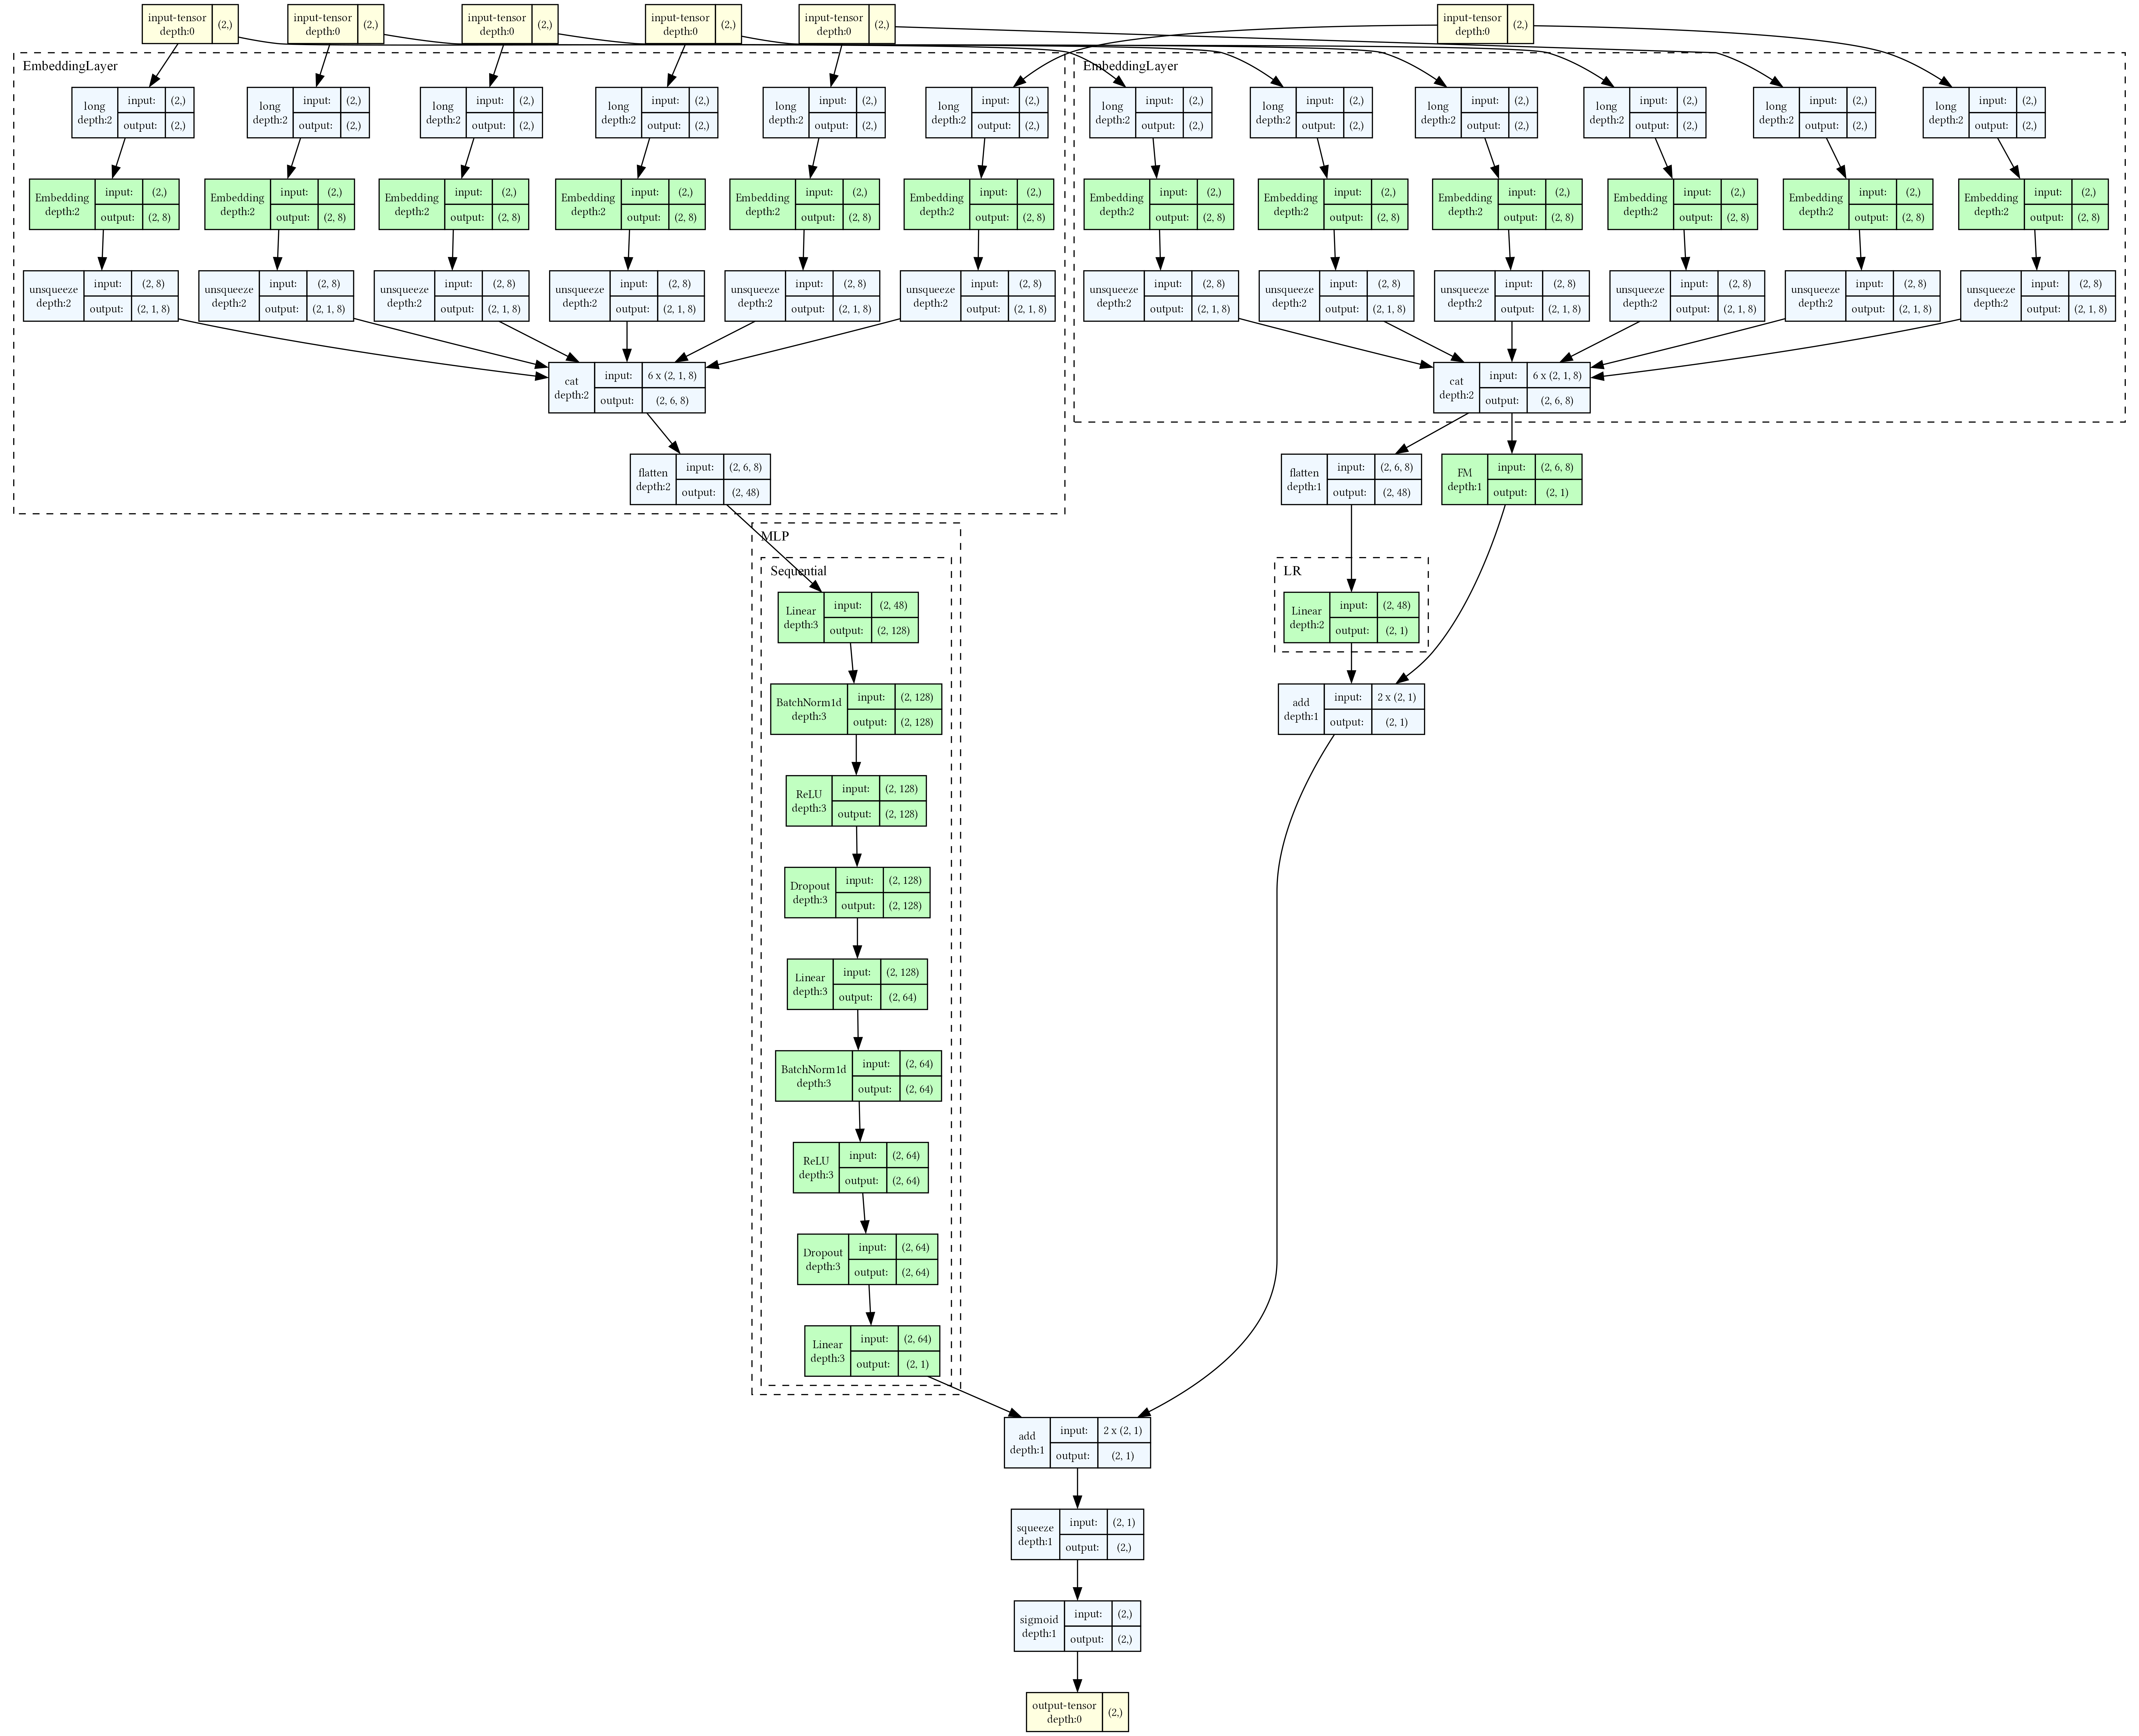

In [18]:
graph = visualize_model(model, depth=40)

以下是DeepFM模型的结构图：  
```text
DeepFM(
  (linear): LR(
    (fc): Linear(in_features=48, out_features=1, bias=True)
  )
  (fm): FM()
  (embedding): EmbeddingLayer(
    (embed_dict): ModuleDict(
      (UserID): Embedding(6040, 8)
      (MovieID): Embedding(3706, 8)
      (Gender): Embedding(2, 8)
      (Age): Embedding(7, 8)
      (Occupation): Embedding(21, 8)
      (Genres): Embedding(18, 8)
    )
    (input_mask): InputMask()
  )
  (mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=48, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
```
该模型一共分为四部分。   
1. EmbeddingLayer (嵌入层)   
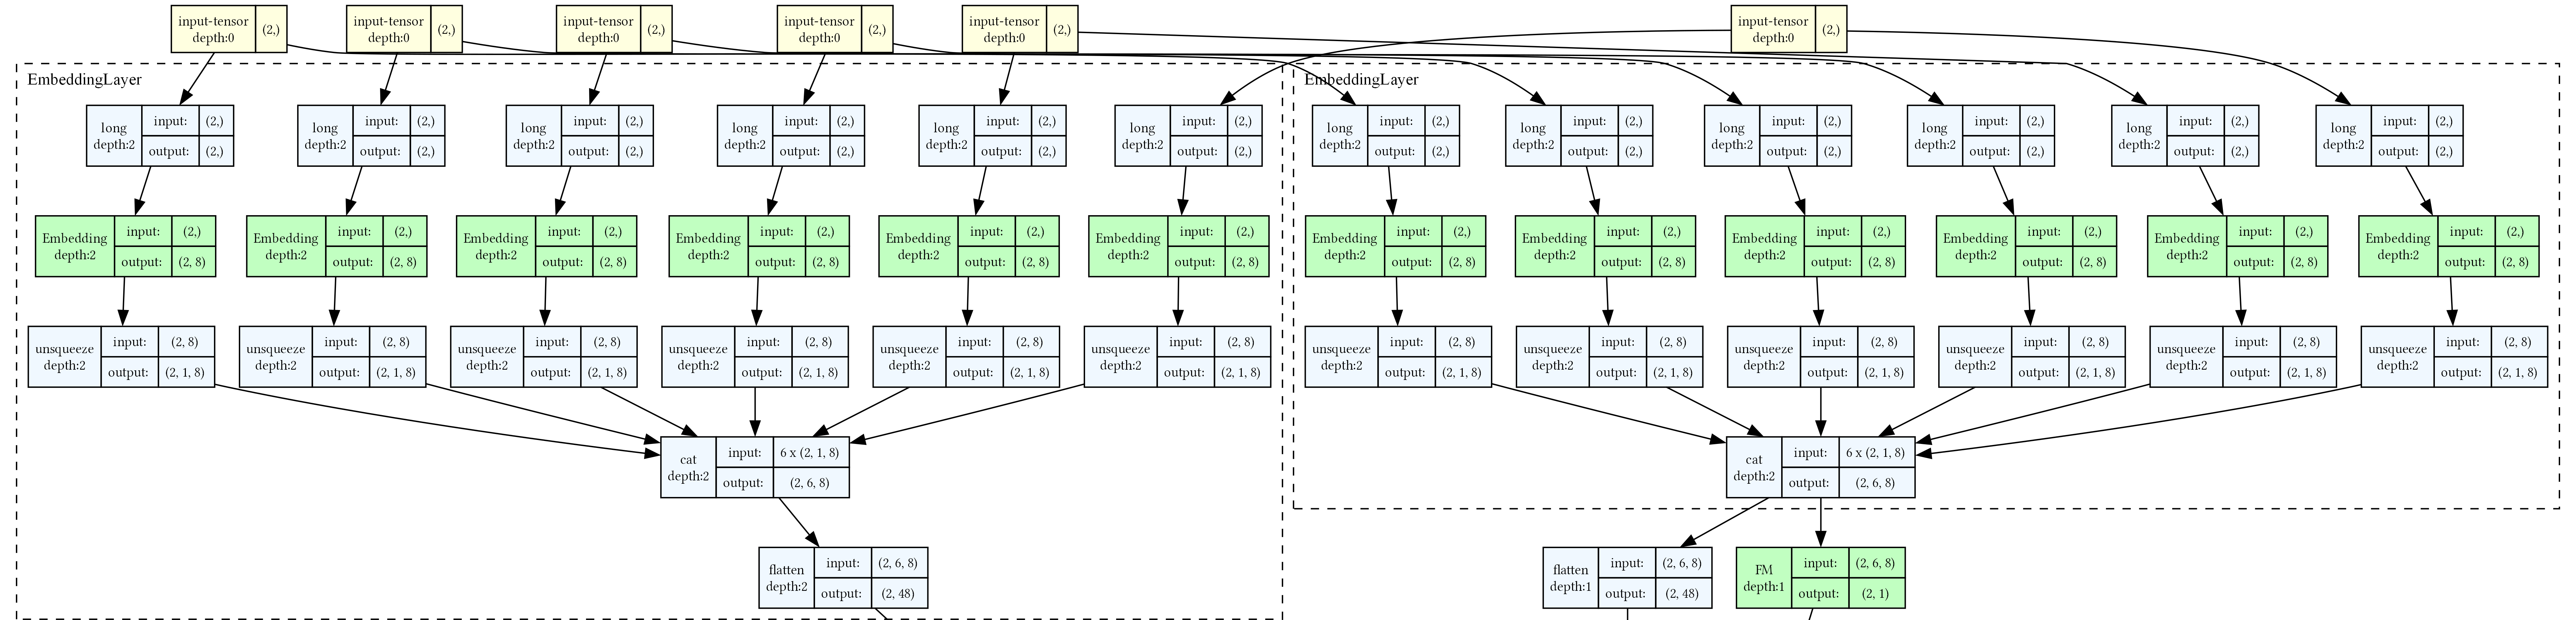
```text
(embedding): EmbeddingLayer(
  (embed_dict): ModuleDict(
    (UserID): Embedding(6040, 8)
    (MovieID): Embedding(3706, 8)
    (Gender): Embedding(2, 8)
    (Age): Embedding(7, 8)
    (Occupation): Embedding(21, 8)
    (Genres): Embedding(18, 8)
  )
)
这个层的主要工作是将类别特征（如UserID, MovieID）从简单的数字索引（例如，用户A的ID是5）转换成有意义的、低维度的数值向量（称为“嵌入向量”或 "Embedding"）。
为什么需要转换？ 
原始的ID号，比如UserID 5 和 6，它们在数值上很接近，但并不代表这两个用户就相似。模型无法直接从这些ID号中学习到有用的信息。
如何转换？ 
EmbeddingLayer 像一个大型的查询表。
以 (UserID): Embedding(6040, 8) 为例：
6040：代表数据集中一共有6040个独立的用户。这个数字来自于对UserID列进行LabelEncoder后的唯一值数量。
8：代表每个用户的嵌入向量的维度。也就是说，模型会用一个包含8个数字的向量来表示每一个用户。
最终输出：
当一条数据（例如，关于用户A看电影B的记录）进入模型时，这个层会为该记录中的每一个类别特征（UserID, MovieID, Gender等）查找并输出其对应的8维向量。
```
2. LR (Linear Regression, 线性部分)  
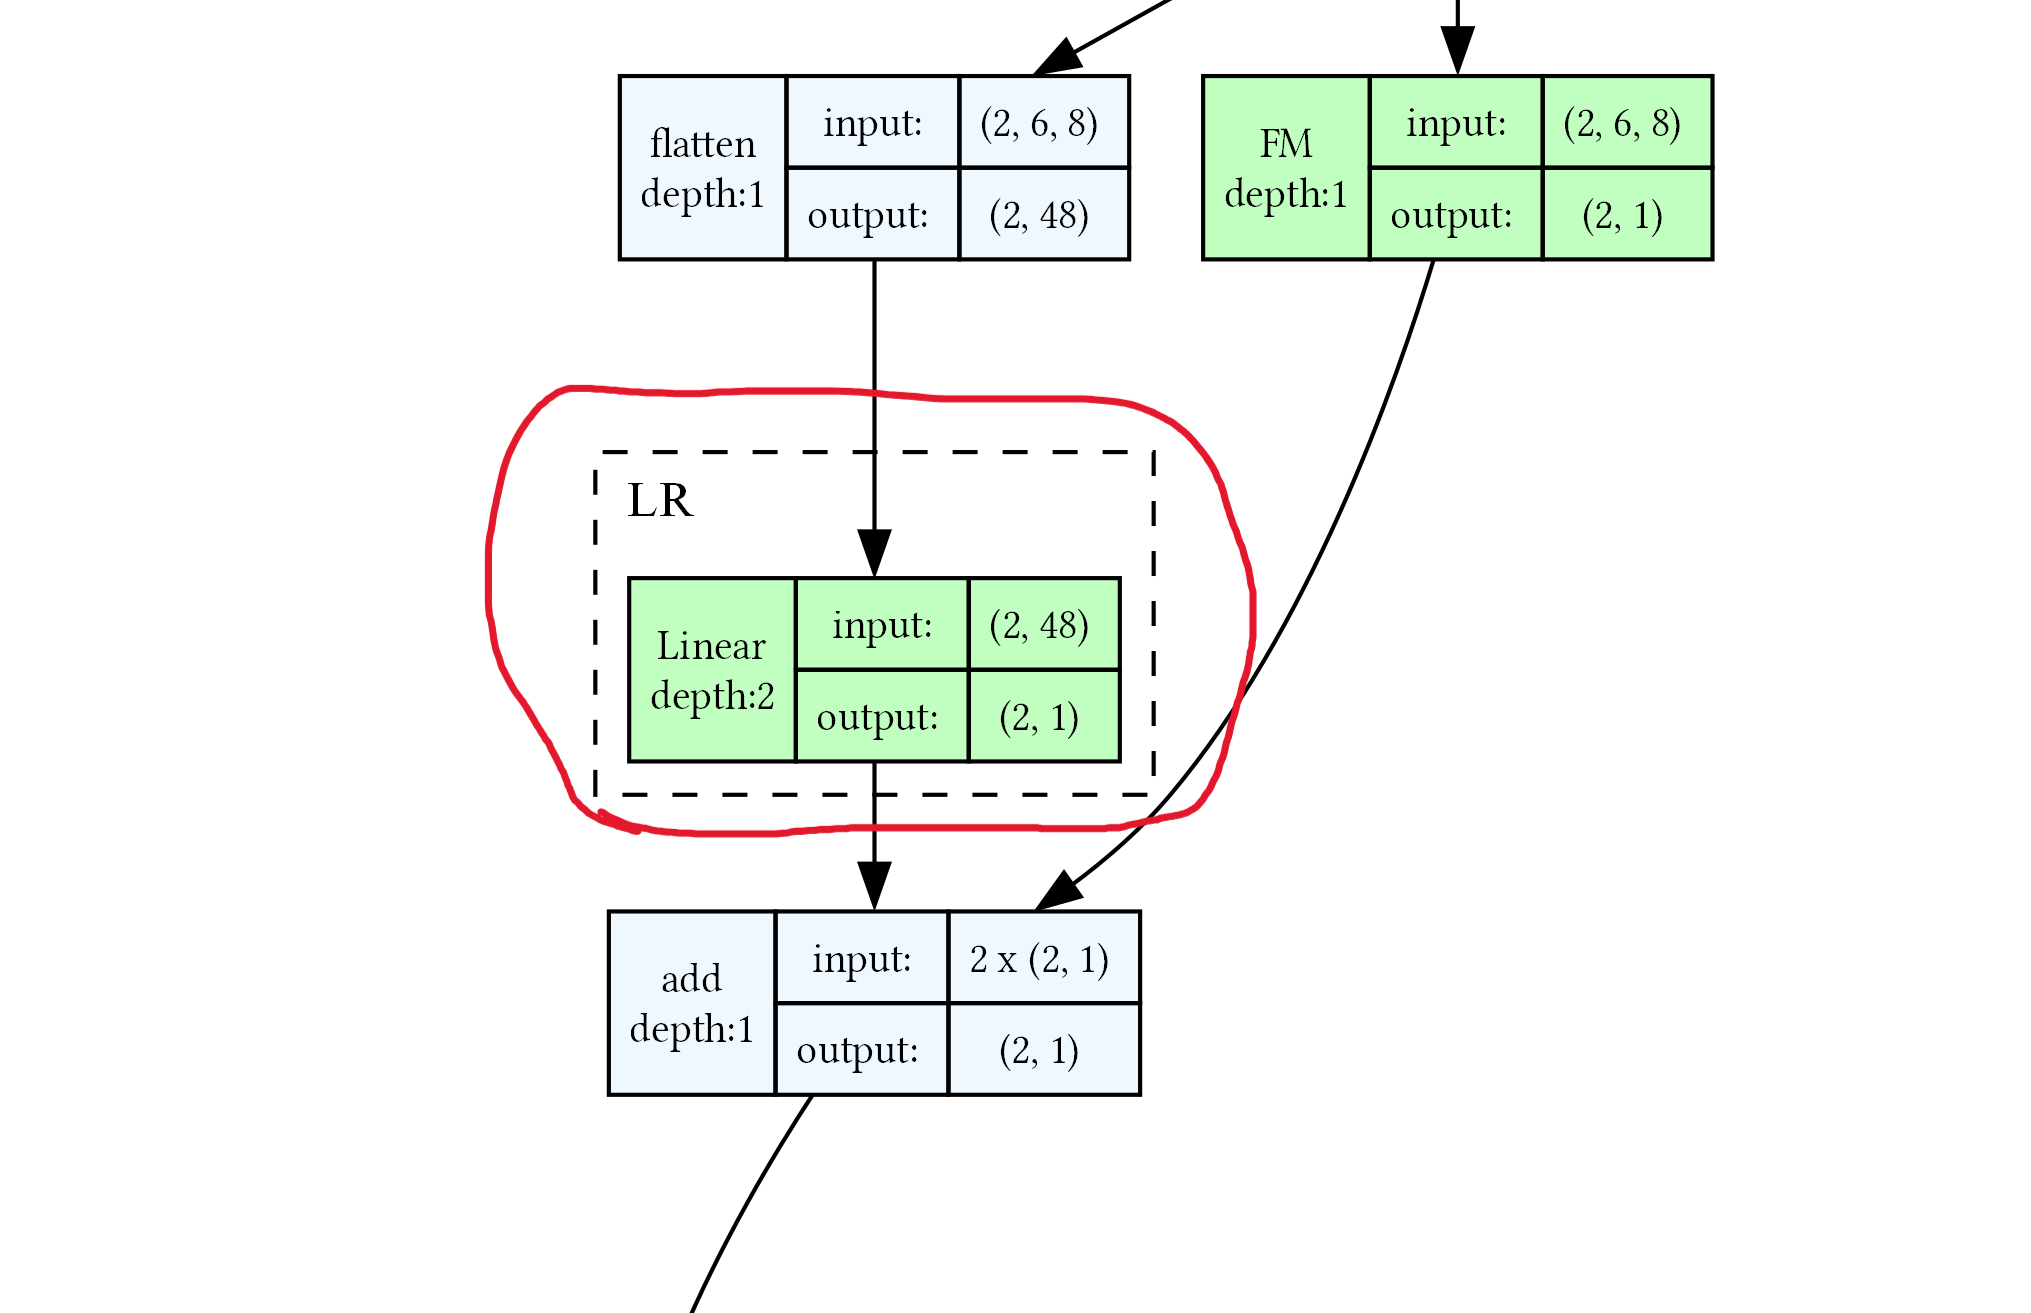
```text
(linear): LR(
  (fc): Linear(in_features=48, out_features=1, bias=True)
)
这个部分用来学习一阶特征 (First-Order Features) 的权重。简单来说，它衡量每个特征独立对最终结果的贡献度，而不考虑特征之间的任何交互。
它回答的问题是：某个电影本身是否就是热门电影？某个用户本身是不是一个活跃的高分用户？它只看单个特征，比如“电影类型是‘喜剧’”这个特征本身是否会增加用户“喜欢”的概率。
如何工作：它为每个特征学习一个权重，然后将它们加权求和，得出一个分数。这个分数代表了所有一阶特征的综合影响。
```
3. FM (Factorization Machine, 交互部分)

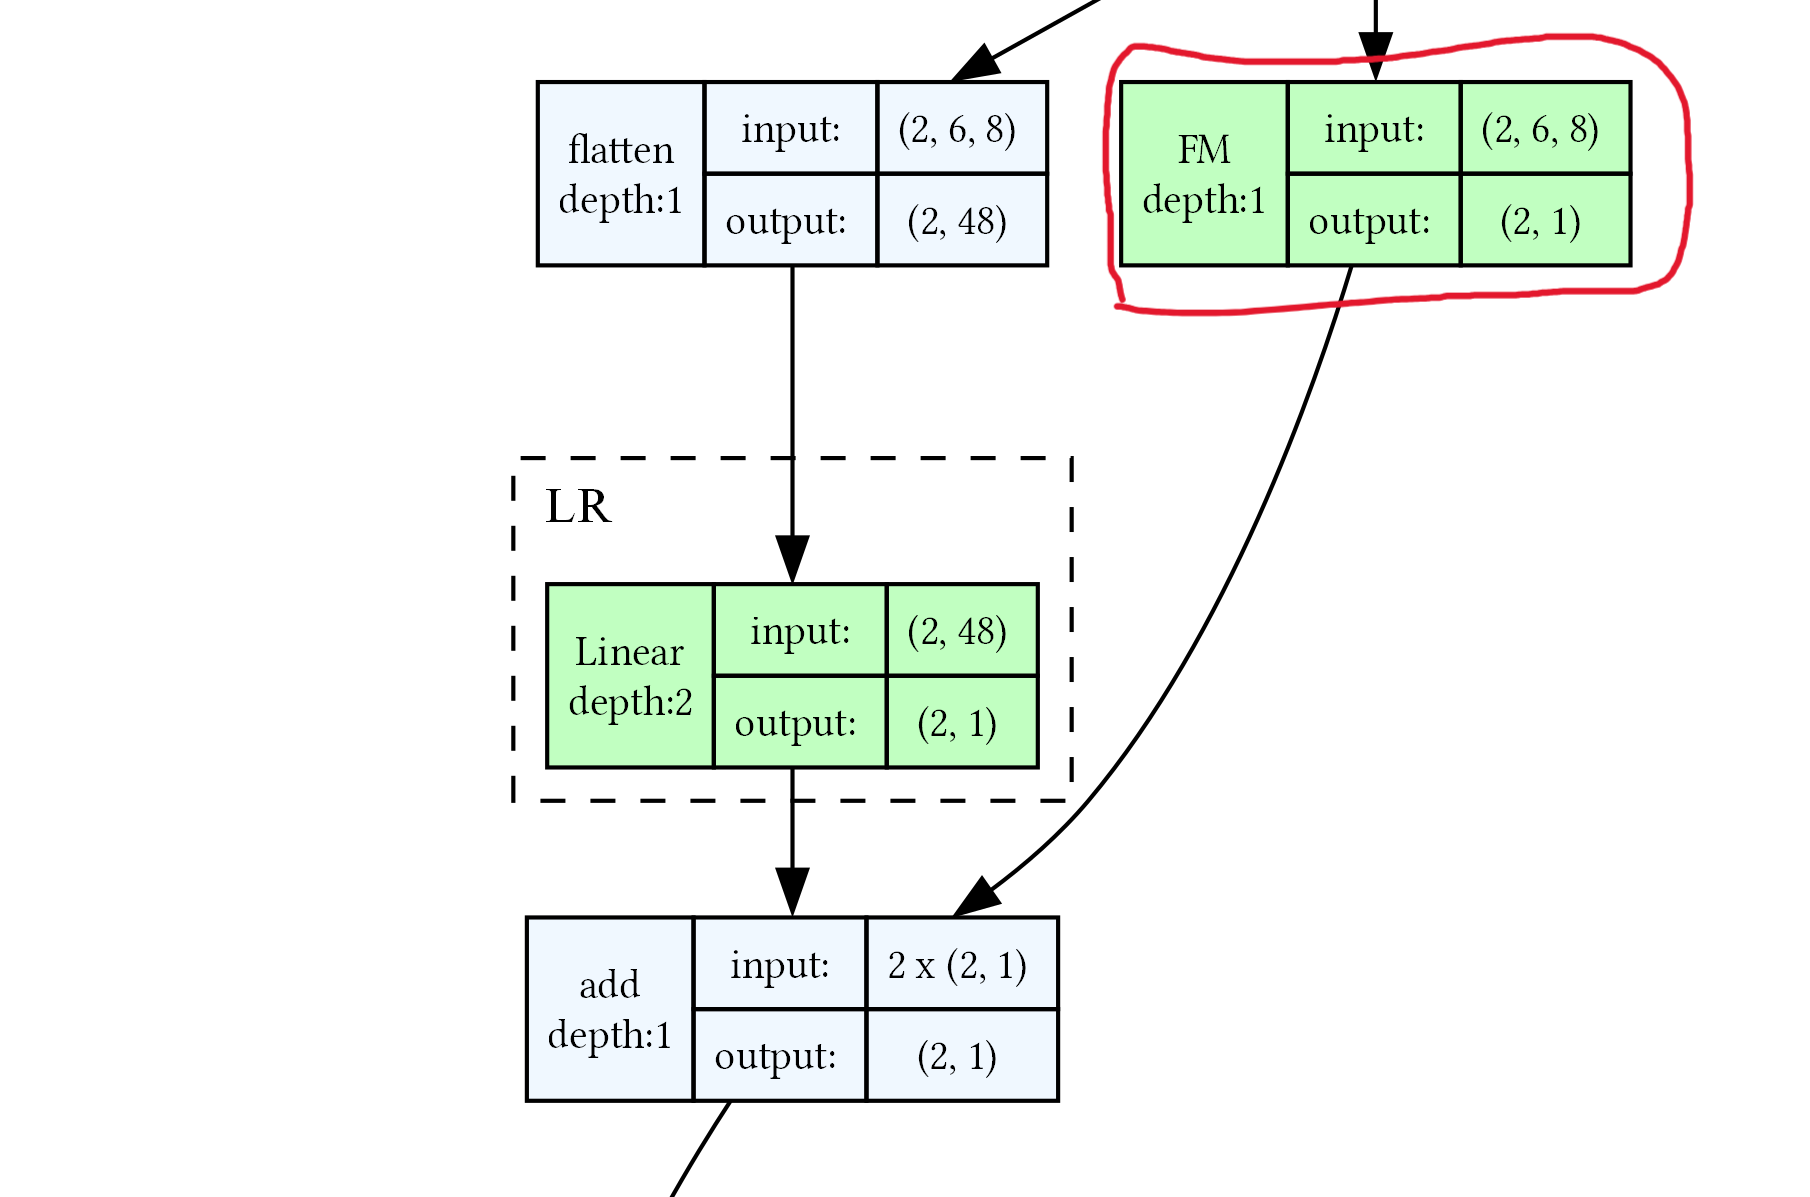
```text
(fm): FM()
这个部分用来学习二阶特征交叉 (Second-Order Feature Interactions)。它衡量任意两个特征组合在一起时的效果。
它回答的问题是：
“特定用户” 和 “特定电影类型” 组合在一起，会产生什么效果？
“特定年龄段” 和 “特定职业” 的用户组合在一起，对电影偏好有什么影响？
如何工作：它利用了第一步中生成的嵌入向量。通过计算任意两个特征的嵌入向量的内积（Dot Product），来衡量这两个特征的交互强度。例如，它会计算 UserID 的嵌入向量和 Genres 的嵌入向量的内积。如果一个用户和一个电影类型的嵌入向量在方向上很相似，它们的内积就会很大，这会增加最终预测为“喜欢”的概率。
```
4. Deep (MLP, 深度部分)

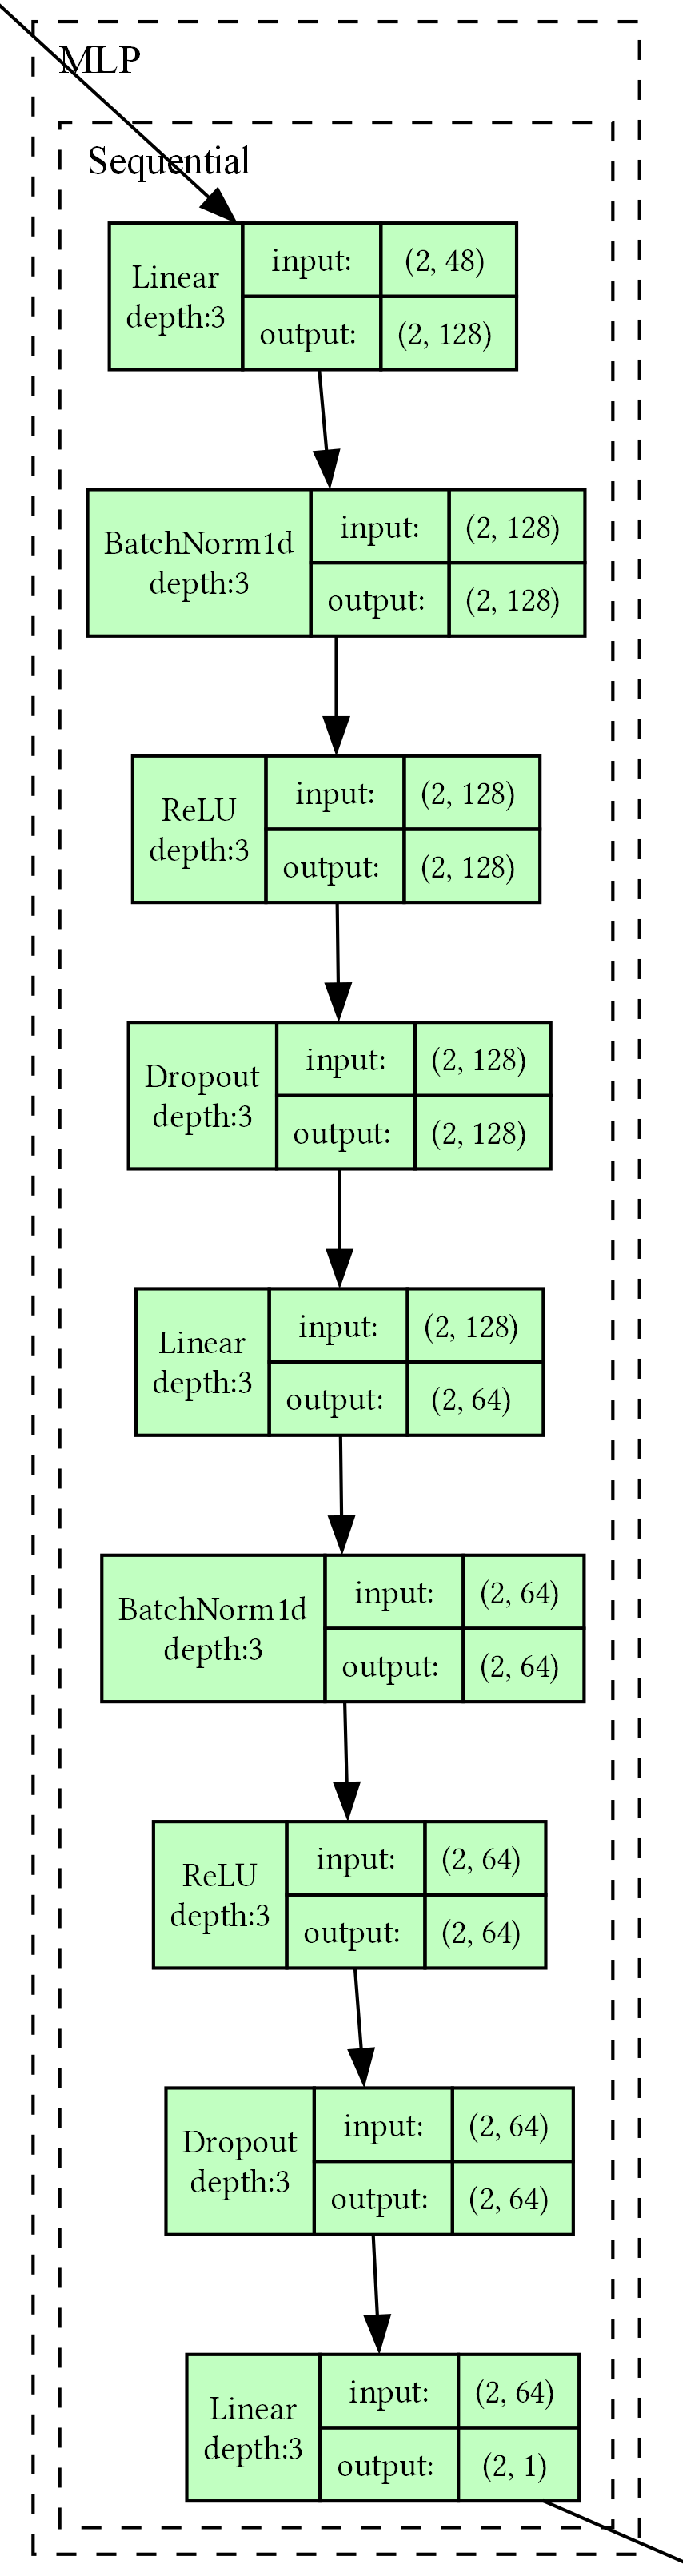
```text
  (mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=48, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=1, bias=True)
    )
  )
这个部分通过多层非线性变换，自动学习高阶的、更复杂的特征交叉。
它回答的问题是：是否存在一些难以手动发现的复杂模式？例如，“年龄在18-24岁（Age）的男性（Gender）程序员（Occupation）是否对科幻（Genre）电影有特别强的偏好？” 这种涉及三个或更多特征的复杂关系，就是高阶交叉。
如何工作：
输入：它将所有类别特征的嵌入向量**拼接（Concatenate）**在一起。因为我们有6个特征（UserID, MovieID, Gender, Age, Occupation, Genres），每个特征的嵌入向量维度是8，所以拼接后的总维度是 6 * 8 = 48。这就是第一层 Linear(in_features=48, ...) 中 in_features=48 的由来。
处理：这个48维的向量会经过一系列的线性层（Linear）、激活函数（ReLU）和正则化层（BatchNorm1d, Dropout）。这个过程让模型可以捕捉到特征之间非常复杂和非线性的关系。
输出：最后，它也输出一个单一的数值，代表从高阶特征交叉中学习到的分数。
```
```text
最后，模型将三部分的预测分数求和，得到了最终分数。
这个最终分数会再通过一个 Sigmoid 函数，转换成一个介于 0 和 1 之间的概率值，表示用户“喜欢”这部电影的可能性。
Linear 部分 提供了基础的、独立的特征贡献。
FM 部分 精准地捕捉了成对特征之间的交互。
MLP 部分 自动探索了所有特征之间潜在的、更深层次的复杂关系。
这种结构让DeepFM既能“记住”简单的模式（像Wide & Deep模型中的Wide部分），又能“泛化”到复杂的、未见过的模式（像Deep部分），因此在CTR预估等任务中表现非常出色。
```
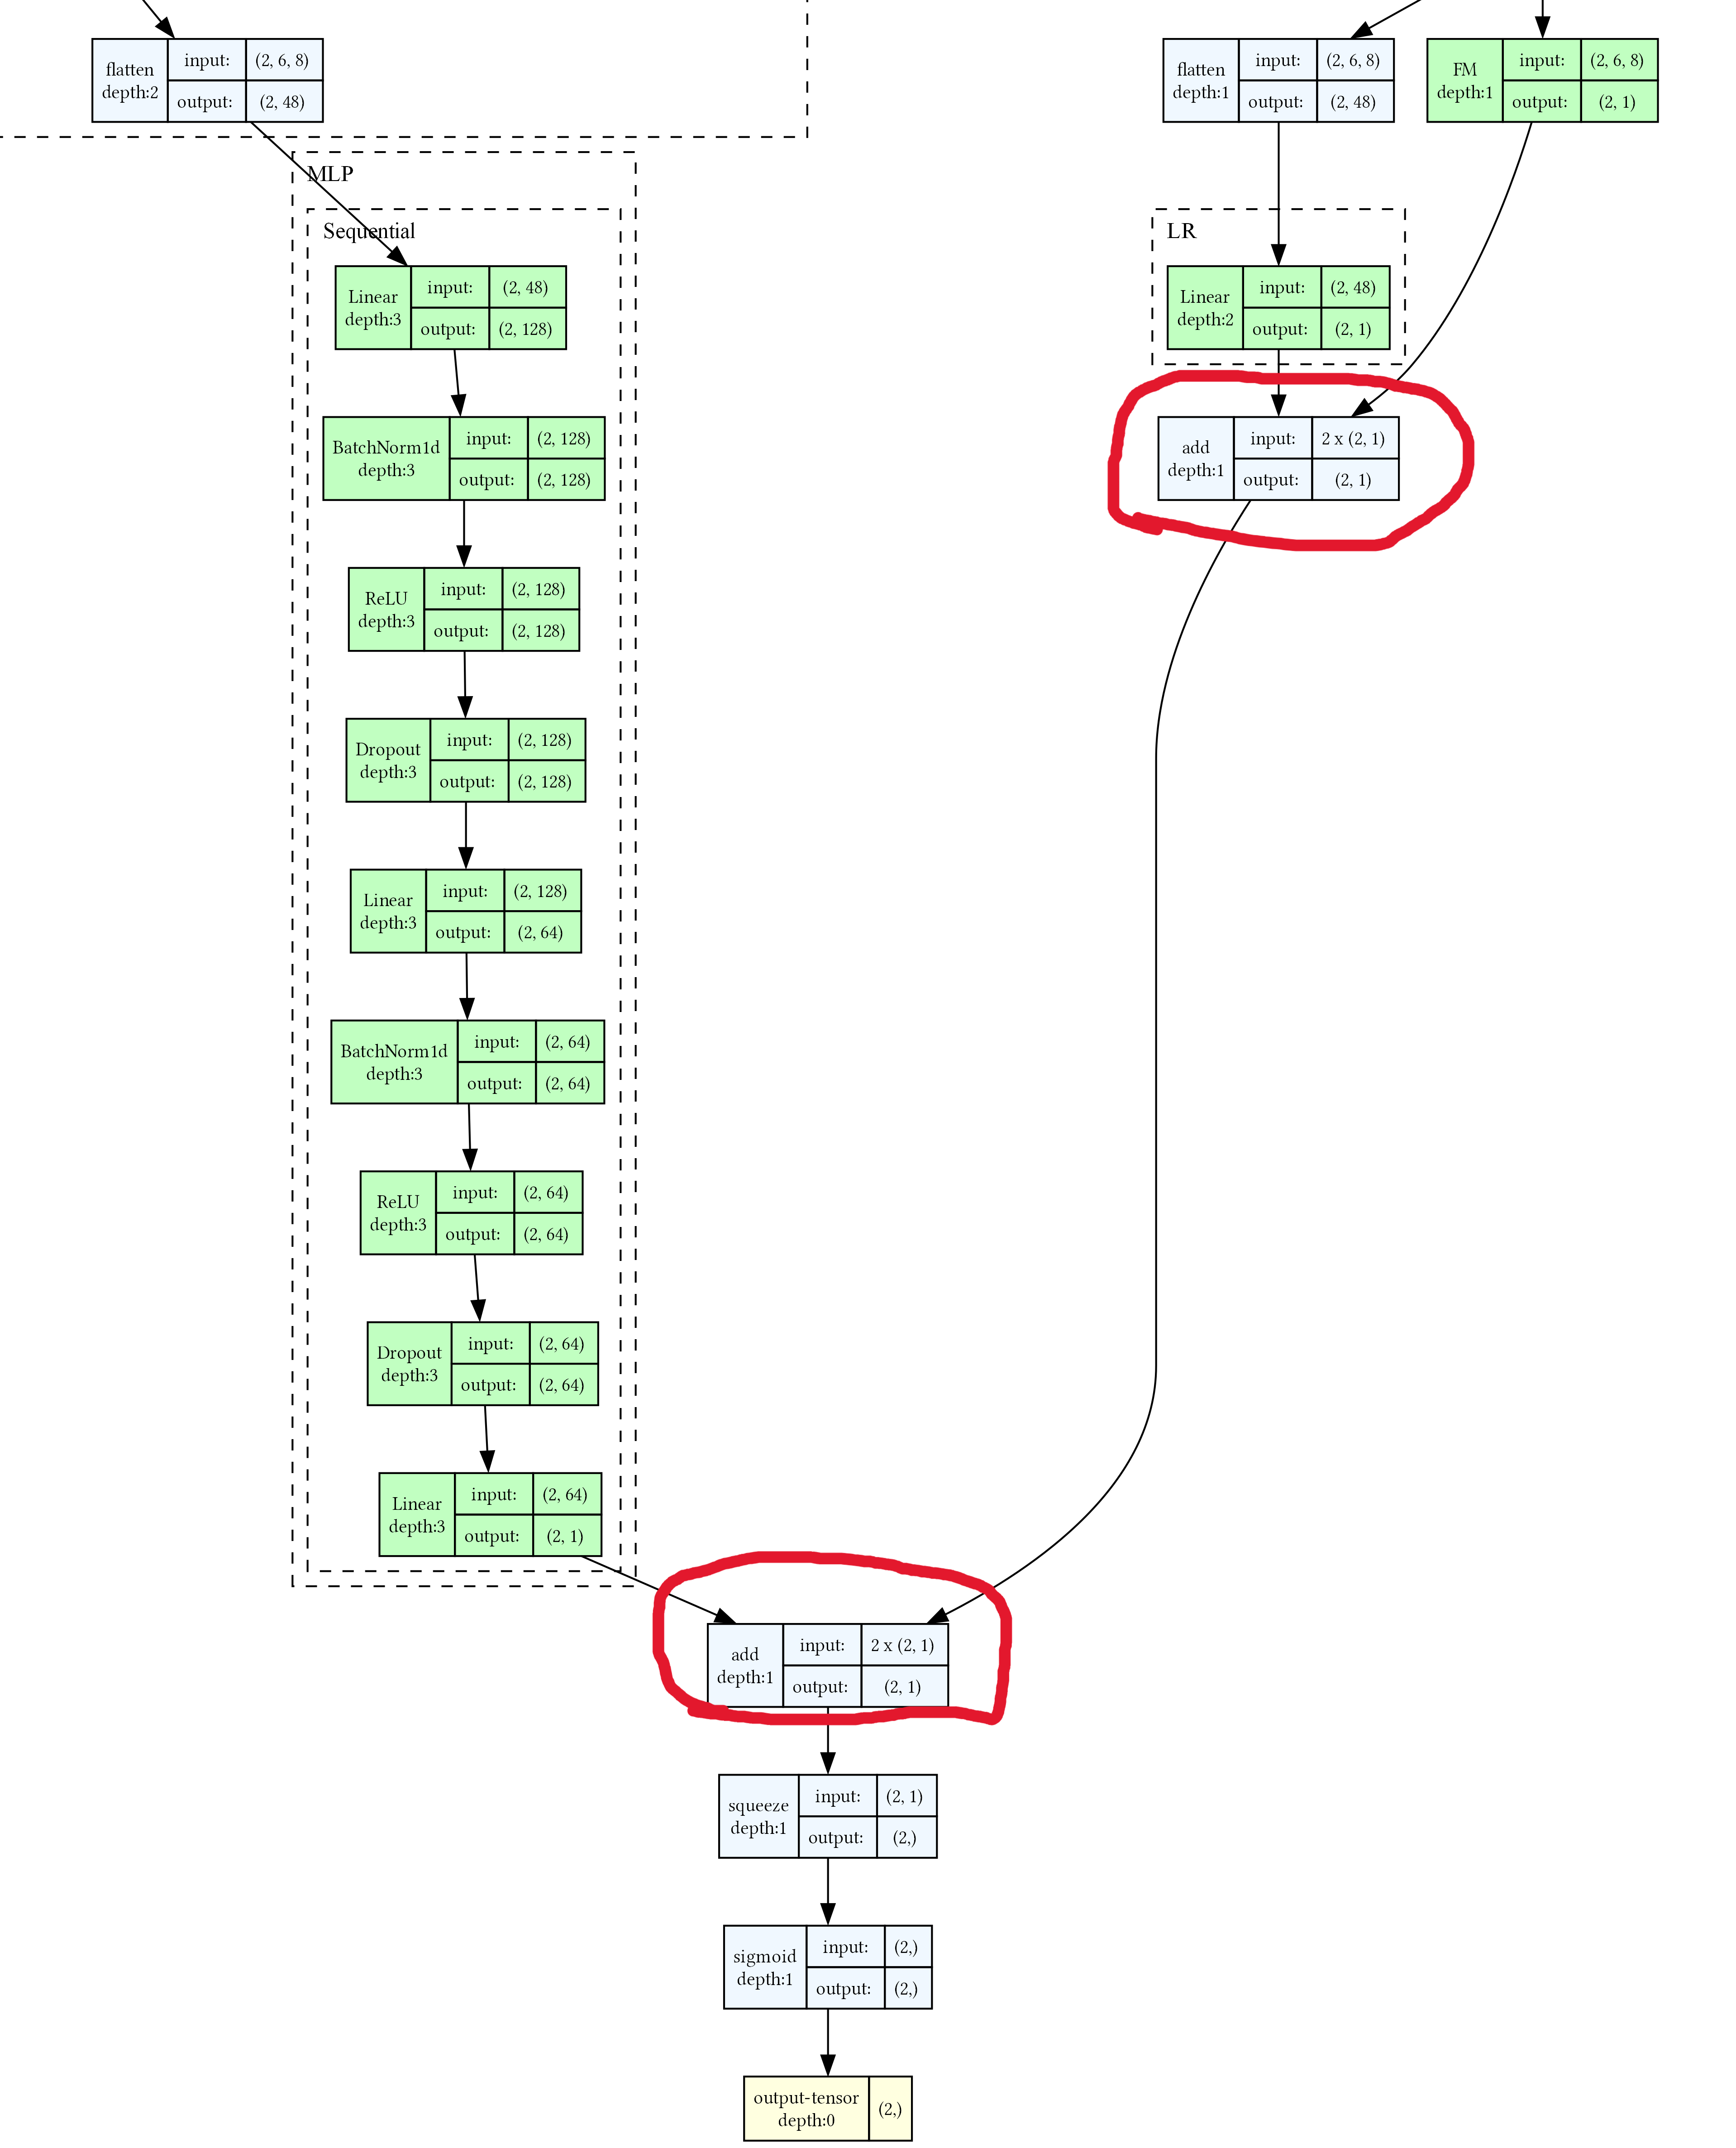
**下段代码作用**：展示模型结构。


In [19]:
print(model)

DeepFM(
  (linear): LR(
    (fc): Linear(in_features=48, out_features=1, bias=True)
  )
  (fm): FM()
  (embedding): EmbeddingLayer(
    (embed_dict): ModuleDict(
      (UserID): Embedding(6040, 8)
      (MovieID): Embedding(3706, 8)
      (Gender): Embedding(2, 8)
      (Age): Embedding(7, 8)
      (Occupation): Embedding(21, 8)
      (Genres): Embedding(18, 8)
    )
    (input_mask): InputMask()
  )
  (mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=48, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
